<a href="https://colab.research.google.com/github/LucasVidalFilho/LucasVidalFilho/blob/main/chocolate%20sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Imports
import matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

df = pd.read_csv("/content/drive/MyDrive/estatistica pucc/projeto temp chocolate/Chocolate Sales.csv")
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184


Limepza Básica do nosso DataFrame

In [ ]:
#Transformando a data tipo string em datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

#Transformando amount em float
df['Amount'] = df['Amount'].str.replace(',','')
df['Amount'] = df['Amount'].str.replace('$','')
df['Amount'] = df['Amount'].astype(float)

Exercício 1: O "Ticket" do Gráfico de Barras (Desempenho por País)

Text(0.5, 1.0, 'Total de Caixas Enviadas por País')

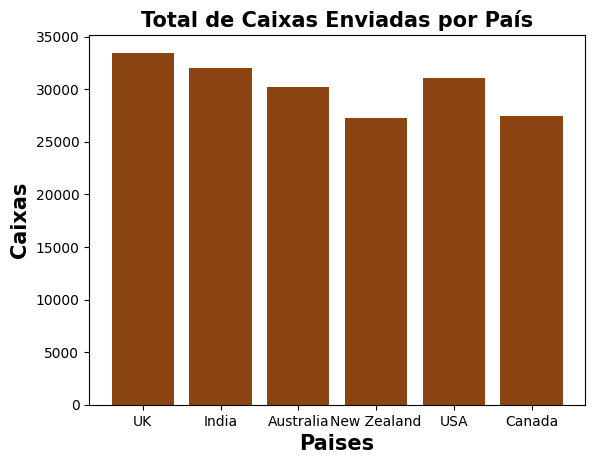

In [ ]:
df_2023 = df[df['Date'].dt.year == 2023].copy()

caixas_por_pais = df_2023.groupby('Country')['Boxes Shipped'].sum()

plt.bar(df['Country'].unique(), caixas_por_pais.values, color='#8B4513')
plt.xlabel('Paises', size=15, weight='bold')
plt.ylabel('Caixas', size=15, weight='bold')
plt.title("Total de Caixas Enviadas por País", weight='bold', size=15)

Exercício 2: O "Ticket" do Gráfico de Dispersão (Correlação)

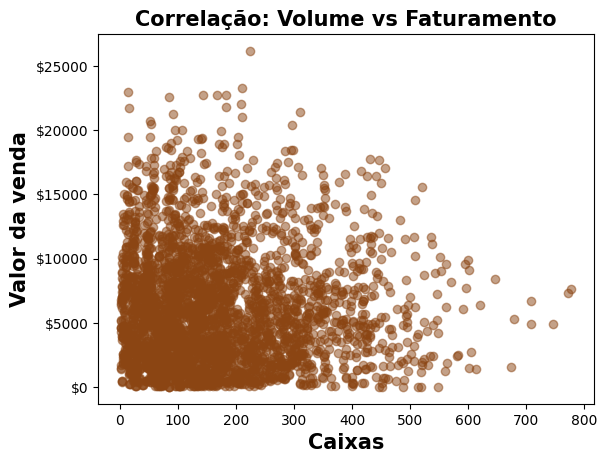

In [ ]:
plt.scatter(df['Boxes Shipped'], df['Amount'], alpha=0.5, color='#8B4513')
plt.xlabel('Caixas', size=15, weight='bold')
plt.ylabel('Valor da venda', size=15, weight='bold')
plt.title("Correlação: Volume vs Faturamento", size=15, weight='bold')

fmt = '${x:.0f}'
tick = mtick.StrMethodFormatter(fmt)
plt.gca().yaxis.set_major_formatter(tick)

Exercício 3: O "Ticket" do Painel Executivo (Subplots)

Text(0.5, 25.722222222222214, 'Volume')

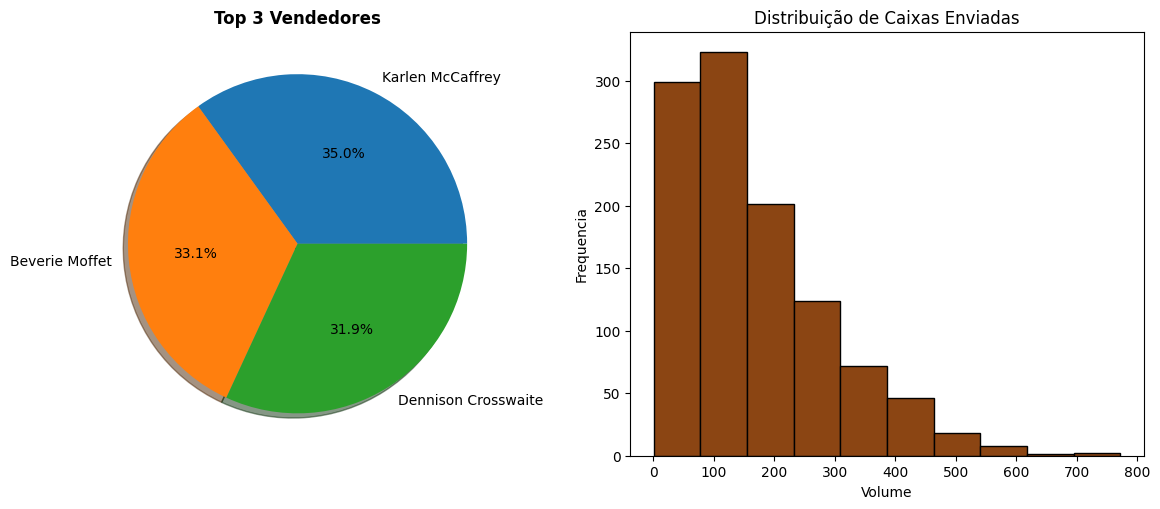

In [ ]:
top3_vendedores = df_2023.groupby('Sales Person')['Boxes Shipped'].sum()
top3_vendedores = top3_vendedores.sort_values(ascending=False).head(3)
top3_vendedores

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(top3_vendedores.values,
        labels=top3_vendedores.index,
        autopct="%1.1f%%",
        shadow= True)

axes[0].set_title('Top 3 Vendedores', weight='bold')

axes[1].hist(df_2023['Boxes Shipped'],
             bins=10,
             color='#8B4513',
             edgecolor='Black'
)
axes[1].set_title('Distribuição de Caixas Enviadas')
plt.tight_layout()
axes[1].set_ylabel("Frequencia")
axes[1].set_xlabel("Volume")


Exercício 4: O "Ticket" da Tendência (Série Temporal e Média Móvel)

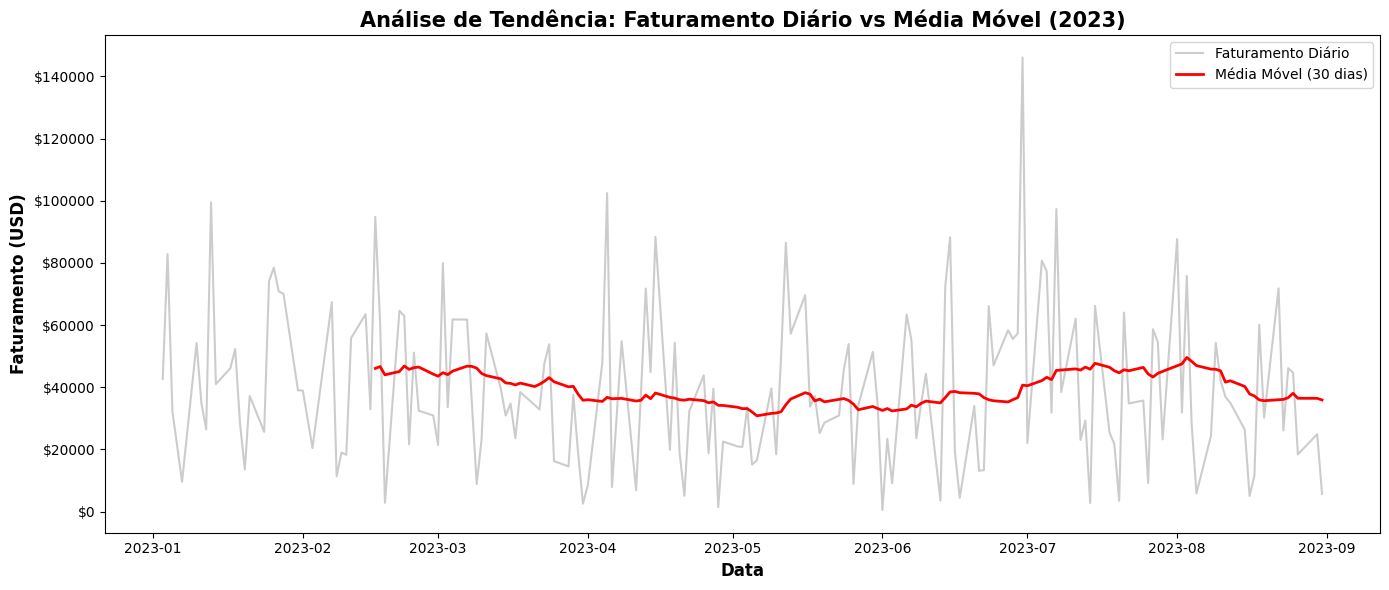

In [ ]:
faturamento2023 = df_2023.groupby('Date')['Amount'].sum()
media_movel = faturamento2023.rolling(window=30).mean()

plt.figure(figsize=(14, 6))

plt.plot(faturamento2023.index, faturamento2023.values, color='gray', alpha=0.4, label='Faturamento Diário')

plt.plot(media_movel.index, media_movel.values, color='red', linewidth=2, label='Média Móvel (30 dias)')

plt.legend()
plt.title('Análise de Tendência: Faturamento Diário vs Média Móvel (2023)', size=15, weight='bold')
plt.xlabel('Data', size=12, weight='bold')
plt.ylabel('Faturamento (USD)', size=12, weight='bold')
fmt = '${x:.0f}'
tick = mtick.StrMethodFormatter(fmt)
plt.gca().yaxis.set_major_formatter(tick)
plt.tight_layout()

Exercício 5: O "Ticket" da Regra 80/20 (Gráfico de Pareto)

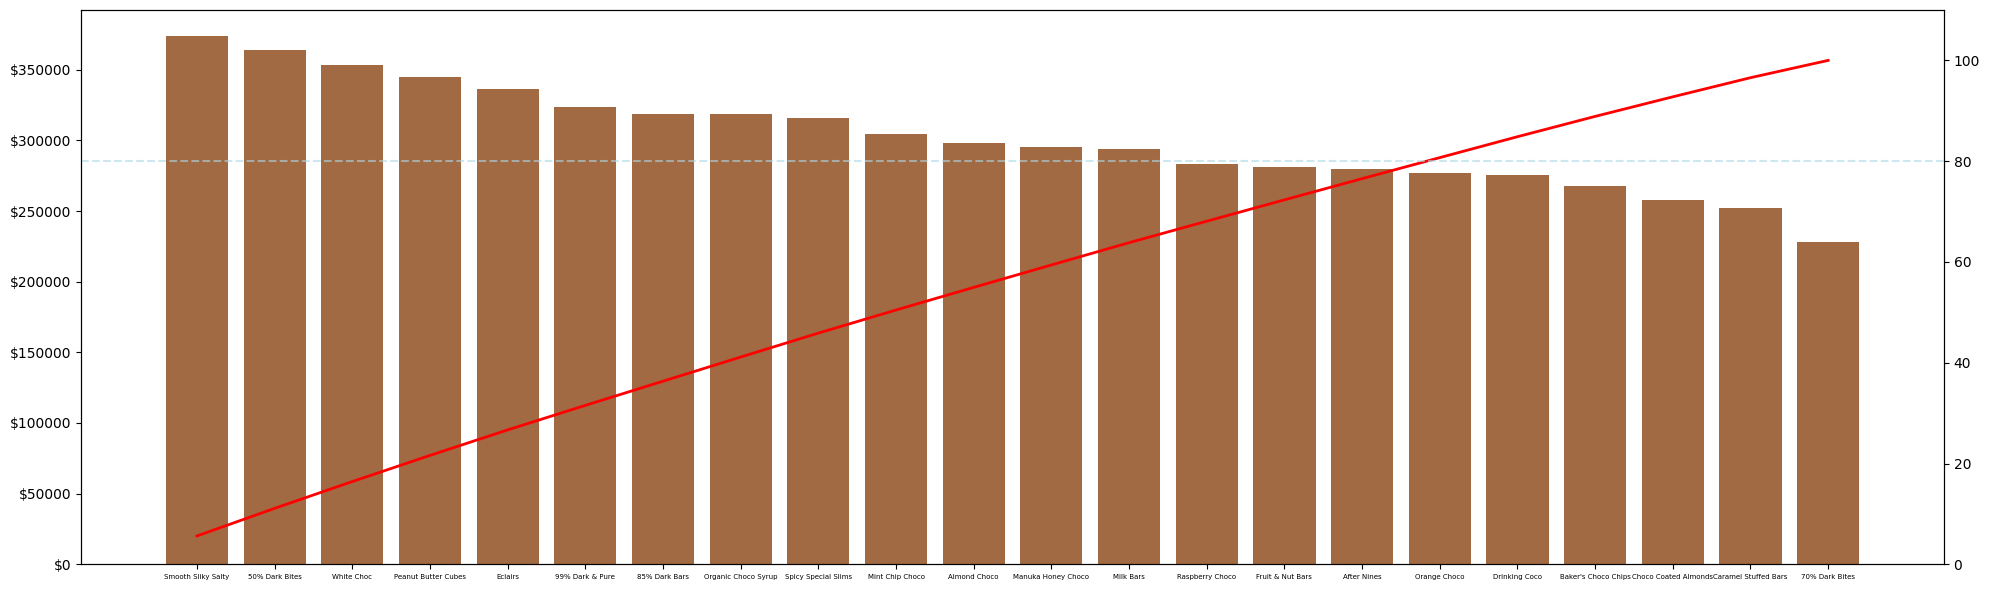

In [ ]:
pareto = df_2023.groupby('Product')['Amount'].sum()
pareto = pareto.sort_values(ascending=False)

soma_total = pareto.sum()
porcentagem_acumulado = (pareto.cumsum() / soma_total)*100

#ax1
fig, ax1 = plt.subplots(figsize=(20, 6))
ax1.bar(pareto.index, pareto.values, color='#8B4513', alpha=0.8)
plt.xticks(fontsize=5)
fmt = '${x:.0f}'
tick = mtick.StrMethodFormatter(fmt)
plt.gca().yaxis.set_major_formatter(tick)

#ax2
ax2 = ax1.twinx()
ax2.plot(pareto.index, porcentagem_acumulado.values, color='red', linewidth=2)
ax2.axhline(y=80, color='lightblue', linestyle='dashed', alpha=0.6)
ax2.set_ylim(0, 110)

plt.tight_layout()


Exercício 6: O "Ticket" de Sazonalidade (Heatmap / Mapa de Calor)

Text(0.5, 1.0, 'Mapa de Calor: Vendas por Dia da Semana e Mês')

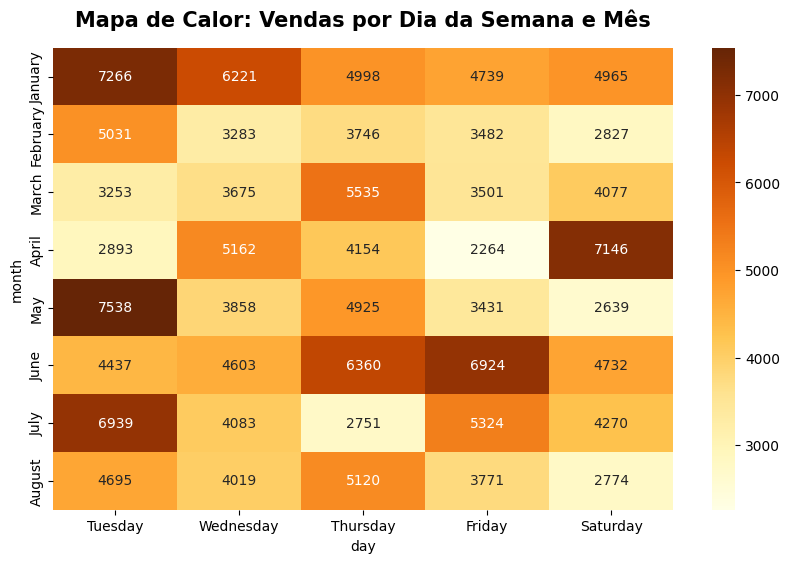

In [ ]:
df_2023['month'] = df_2023['Date'].dt.month_name()
df_2023['day'] = df_2023['Date'].dt.day_name()

ordem_meses = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August']
ordem_dias = ['Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

matriz = pd.pivot_table(
    data=df_2023,
    values='Boxes Shipped',
    index='month',
    columns='day',
    aggfunc='sum'
)
matriz = matriz.reindex(ordem_meses)
matriz = matriz.reindex(columns=ordem_dias)

plt.figure(figsize=(10, 6))
sns.heatmap(matriz, cmap='YlOrBr', annot=True, fmt='.0f')

plt.title('Mapa de Calor: Vendas por Dia da Semana e Mês', size=15, weight='bold', pad=15)